TensorFlow version: 2.20.0
GPU detectada: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]



## 1. Carga del dataset

Se utiliza el dataset Fashion-MNIST, que contiene imágenes en escala de grises de prendas de vestir.

Cada imagen tiene un tamaño de 28x28 píxeles y pertenece a una de 10 clases posibles.

La data se carga directamente desde Keras mediante:

`fashion_mnist.load_data()`


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Forma original x_train_full: (60000, 28, 28)
Forma original y_train_full: (60000,)
Forma original x_test_full: (10000, 28, 28)
Forma original y_test_full: (10000,)



## 2. Visualización inicial de datos

Antes de entrenar los modelos, se visualizan algunas imágenes del dataset para confirmar que los datos fueron cargados correctamente.

Esto permite verificar las clases y la estructura visual del problema de clasificación.


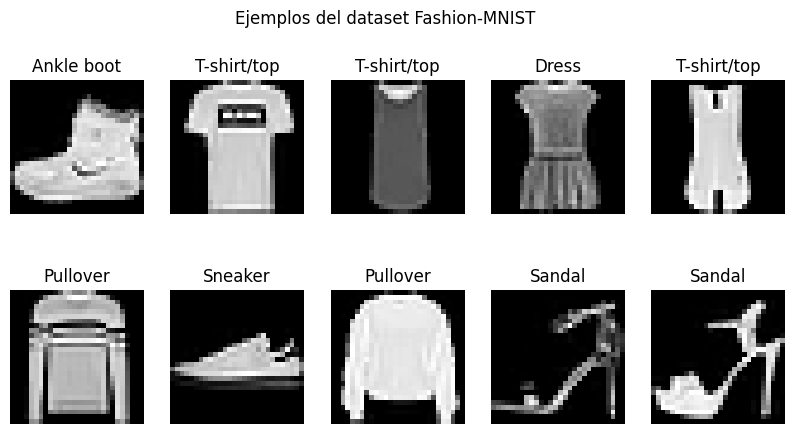


## 3. Preprocesamiento de datos

Las imágenes se normalizan dividiendo sus valores por 255. Esto deja los píxeles en un rango entre 0 y 1.

Además, se agrega una dimensión extra para que las imágenes sean compatibles con capas convolucionales.

Originalmente, cada imagen tiene forma:

`(28, 28)`

Luego del preprocesamiento queda con forma:

`(28, 28, 1)`

Para reducir el tiempo de ejecución, se utilizarán:

- 15.000 imágenes para entrenamiento
- 5.000 imágenes para validación
- 5.000 imágenes para test


x_train: (15000, 28, 28, 1)
y_train: (15000,)
x_val: (5000, 28, 28, 1)
y_val: (5000,)
x_test: (5000, 28, 28, 1)
y_test: (5000,)



## 4. Funciones auxiliares

Se crean funciones reutilizables para:

- Compilar modelos
- Graficar accuracy y loss
- Evaluar modelos
- Guardar los resultados en una tabla comparativa

Para acelerar la evaluación, las métricas de entrenamiento se calcularán sobre una muestra de 3.000 registros.



## 5. Modelo Baseline

El modelo baseline corresponde al modelo base utilizado en la Evaluación Parcial 1.

Este modelo se usa como referencia para comparar el impacto de las técnicas de regularización.

La arquitectura base utiliza:

- Conv2D
- MaxPooling2D
- Conv2D
- MaxPooling2D
- Flatten
- Dense
- Dropout
- Dense de salida con Softmax

Este modelo permitirá observar si existe diferencia entre el rendimiento de entrenamiento y validación.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.6703 - loss: 0.9275 - val_accuracy: 0.7794 - val_loss: 0.5808
Epoch 2/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7995 - loss: 0.5455 - val_accuracy: 0.8202 - val_loss: 0.4843
Epoch 3/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8309 - loss: 0.4672 - val_accuracy: 0.8428 - val_loss: 0.4384


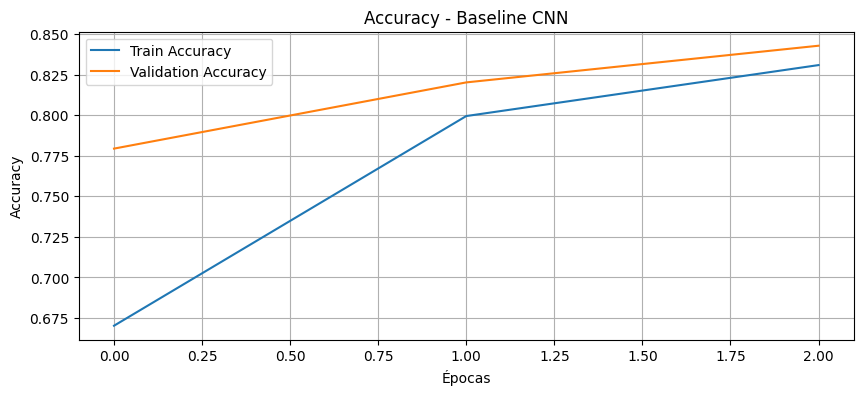

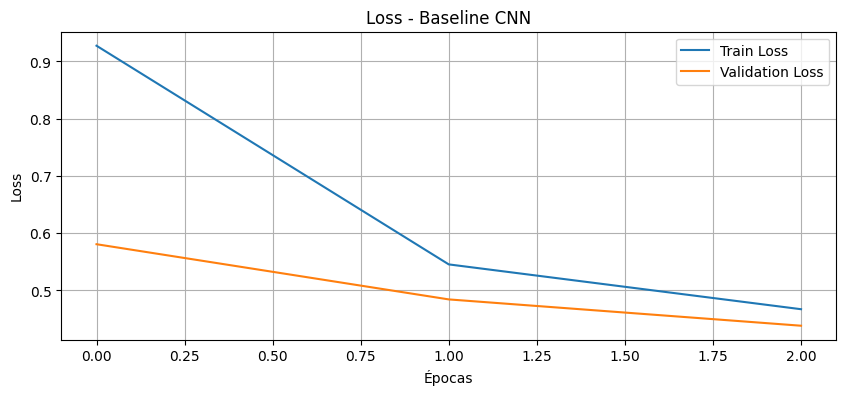

RESULTADOS: Baseline CNN
Train Accuracy:       0.8607
Validation Accuracy:  0.8428
Gap Accuracy:         0.0179
Validation Precision: 0.8425
Validation Recall:    0.8446
Validation F1-score:  0.8378



## 6. L2 Regularization

La regularización L2 penaliza pesos grandes dentro del modelo.

Esto ayuda a reducir el sobreajuste, evitando que la red memorice excesivamente los datos de entrenamiento.

Se prueban dos valores de lambda:

- 0.001
- 0.01

Un valor pequeño aplica una penalización suave, mientras que un valor más alto aplica una penalización más fuerte.

El objetivo es observar cuál valor reduce mejor el gap entre entrenamiento y validación.


Epoch 1/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - accuracy: 0.6624 - loss: 1.1405 - val_accuracy: 0.7808 - val_loss: 0.7594
Epoch 2/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7926 - loss: 0.7271 - val_accuracy: 0.8228 - val_loss: 0.6510
Epoch 3/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8229 - loss: 0.6445 - val_accuracy: 0.8378 - val_loss: 0.5946


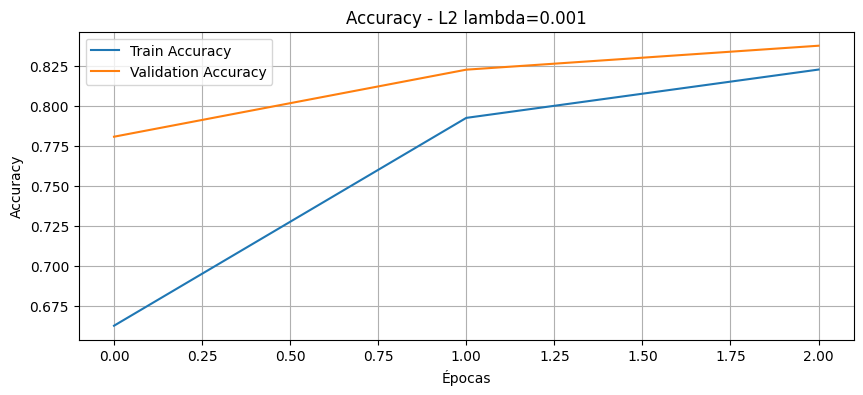

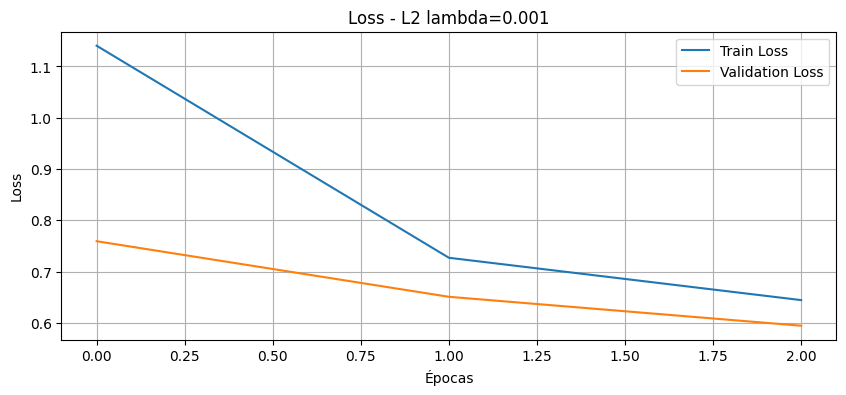

RESULTADOS: L2 lambda=0.001
Train Accuracy:       0.8557
Validation Accuracy:  0.8378
Gap Accuracy:         0.0179
Validation Precision: 0.8371
Validation Recall:    0.8385
Validation F1-score:  0.8364
Epoch 1/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.6275 - loss: 1.9583 - val_accuracy: 0.7708 - val_loss: 1.0909
Epoch 2/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7648 - loss: 1.0104 - val_accuracy: 0.7862 - val_loss: 0.8674
Epoch 3/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7814 - loss: 0.8624 - val_accuracy: 0.7990 - val_loss: 0.7923


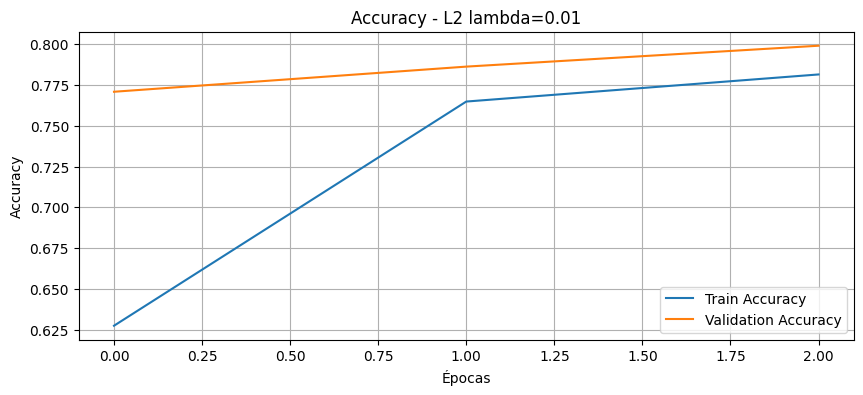

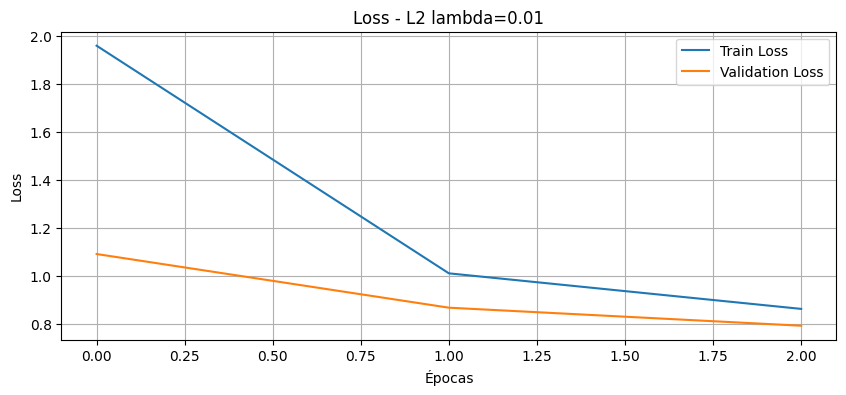

RESULTADOS: L2 lambda=0.01
Train Accuracy:       0.8177
Validation Accuracy:  0.7990
Gap Accuracy:         0.0187
Validation Precision: 0.7955
Validation Recall:    0.8011
Validation F1-score:  0.7857



## 7. Dropout

Dropout desactiva aleatoriamente una proporción de neuronas durante el entrenamiento.

Esto permite que la red no dependa de neuronas específicas y ayuda a mejorar la generalización.

Se prueban tres tasas:

- 0.2
- 0.5
- 0.8

Una tasa baja puede tener poco efecto regularizador.

Una tasa demasiado alta puede afectar negativamente el aprendizaje, ya que elimina demasiada información durante el entrenamiento.


Epoch 1/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.6751 - loss: 0.8981 - val_accuracy: 0.7748 - val_loss: 0.5915
Epoch 2/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7991 - loss: 0.5371 - val_accuracy: 0.8230 - val_loss: 0.4869
Epoch 3/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8319 - loss: 0.4600 - val_accuracy: 0.8464 - val_loss: 0.4307


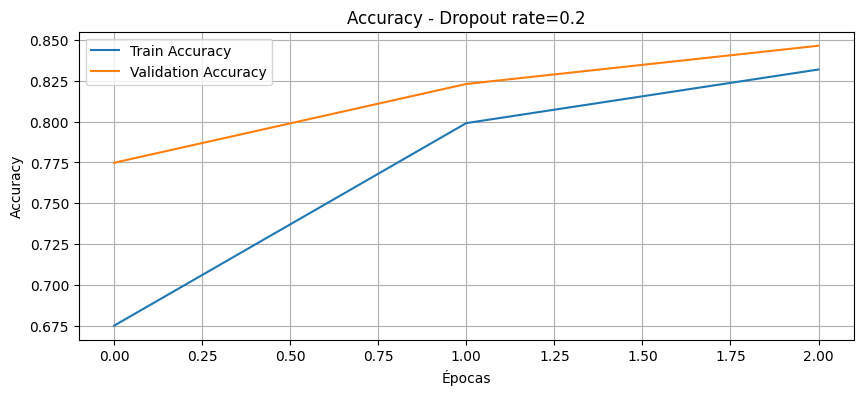

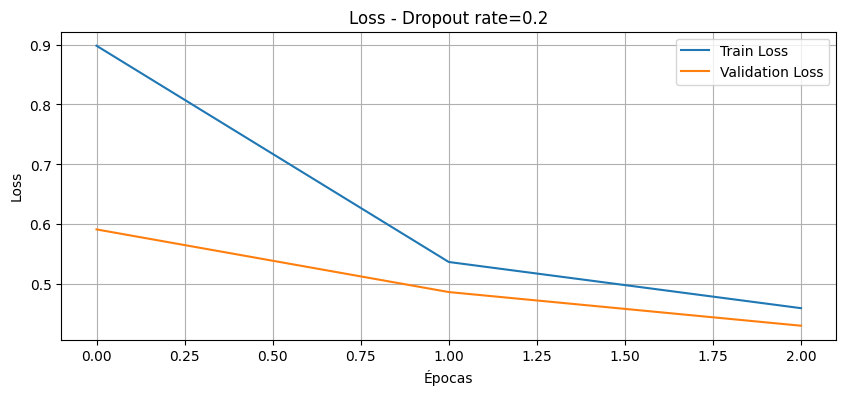

RESULTADOS: Dropout rate=0.2
Train Accuracy:       0.8610
Validation Accuracy:  0.8464
Gap Accuracy:         0.0146
Validation Precision: 0.8459
Validation Recall:    0.8472
Validation F1-score:  0.8454
Epoch 1/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.6622 - loss: 0.9561 - val_accuracy: 0.7908 - val_loss: 0.5648
Epoch 2/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7867 - loss: 0.5811 - val_accuracy: 0.8194 - val_loss: 0.4761
Epoch 3/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8163 - loss: 0.4963 - val_accuracy: 0.8364 - val_loss: 0.4310


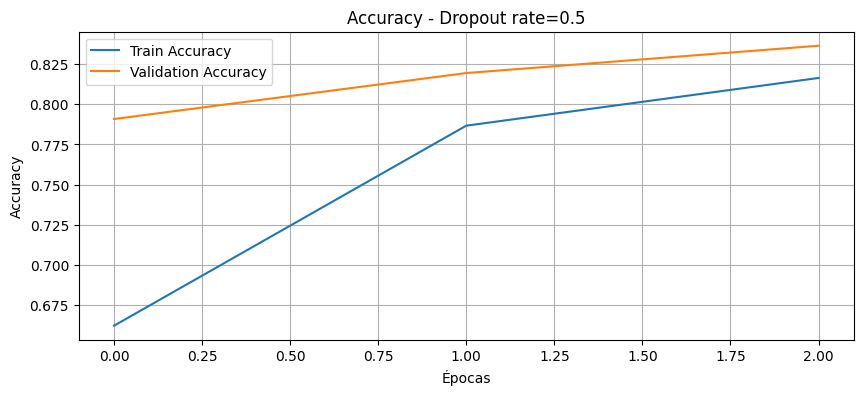

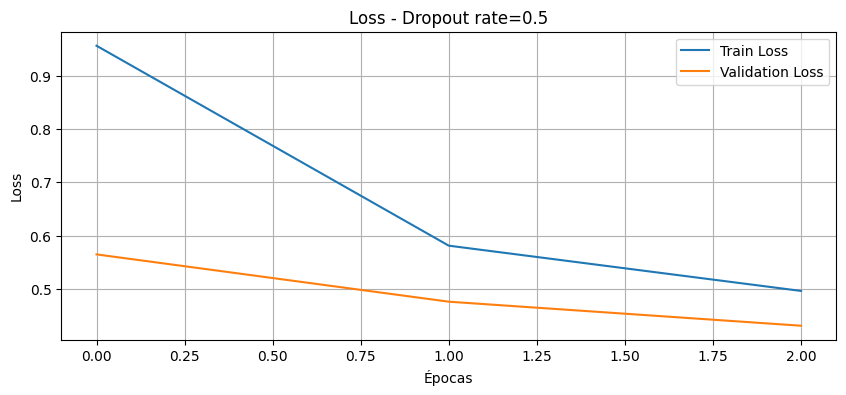

RESULTADOS: Dropout rate=0.5
Train Accuracy:       0.8557
Validation Accuracy:  0.8364
Gap Accuracy:         0.0193
Validation Precision: 0.8352
Validation Recall:    0.8377
Validation F1-score:  0.8344
Epoch 1/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.5257 - loss: 1.3302 - val_accuracy: 0.7570 - val_loss: 0.6669
Epoch 2/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6753 - loss: 0.8819 - val_accuracy: 0.7866 - val_loss: 0.5759
Epoch 3/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7084 - loss: 0.7806 - val_accuracy: 0.7920 - val_loss: 0.5326


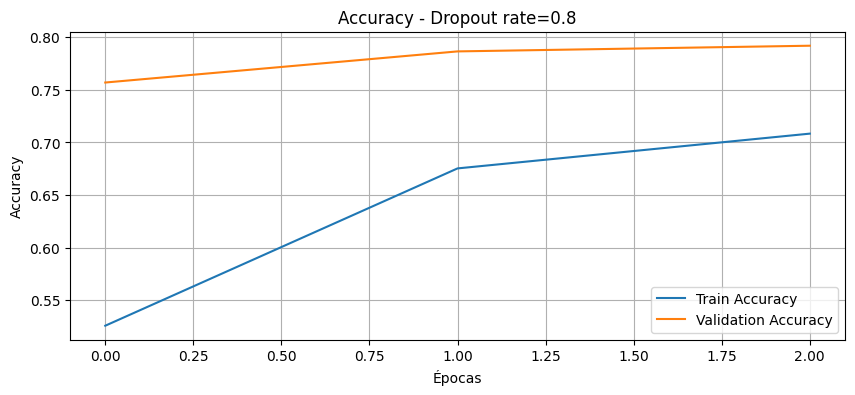

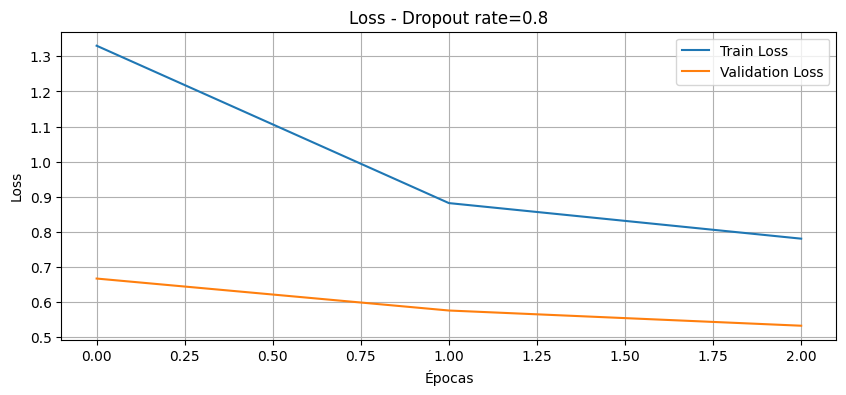

RESULTADOS: Dropout rate=0.8
Train Accuracy:       0.8117
Validation Accuracy:  0.7920
Gap Accuracy:         0.0197
Validation Precision: 0.7837
Validation Recall:    0.7939
Validation F1-score:  0.7811



## 8. Batch Normalization

Batch Normalization normaliza las activaciones intermedias del modelo.

Esto puede estabilizar el entrenamiento y mejorar la convergencia.

En esta arquitectura se ubica BatchNormalization después de la capa convolucional o densa y antes de la activación ReLU.

Esto permite normalizar la salida de la capa antes de aplicar la función de activación.


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,930 (882.54 KB)

 Trainable params: 225,482 (880.79 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - accuracy: 0.7941 - loss: 0.5948 - val_accuracy: 0.1018 - val_loss: 2.2897
Epoch 2/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8731 - loss: 0.3629 - val_accuracy: 0.3694 - val_loss: 1.8798
Epoch 3/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8939 - loss: 0.2993 - val_accuracy: 0.6462 - val_loss: 1.0013


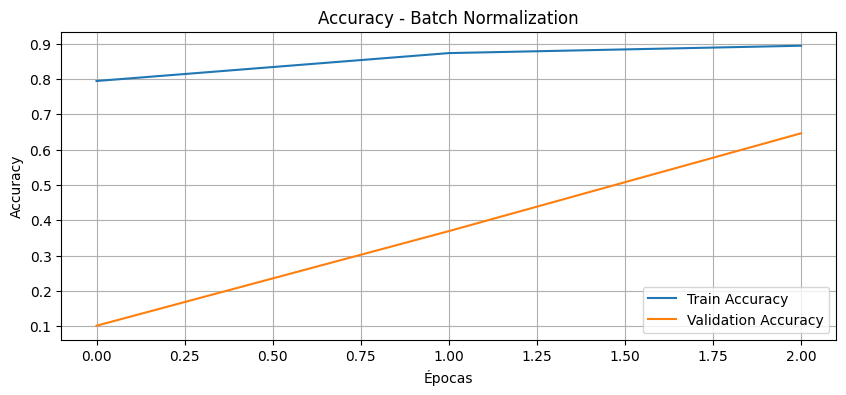

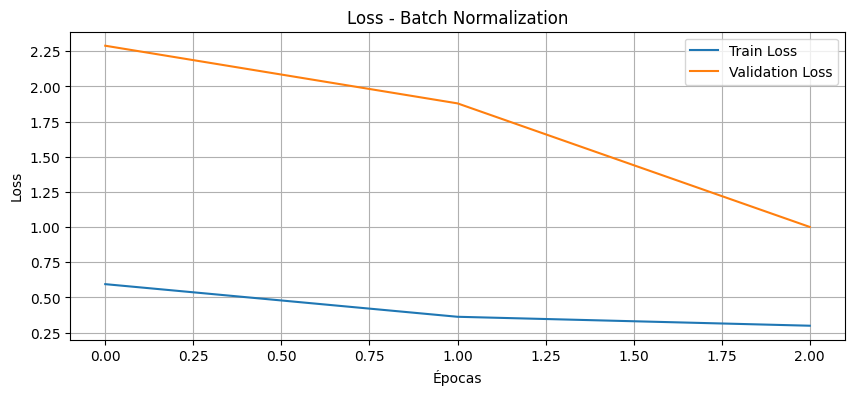

RESULTADOS: Batch Normalization
Train Accuracy:       0.6667
Validation Accuracy:  0.6462
Gap Accuracy:         0.0205
Validation Precision: 0.7903
Validation Recall:    0.6503
Validation F1-score:  0.5972



## 9. Early Stopping

Early Stopping detiene el entrenamiento cuando la pérdida de validación deja de mejorar.

Se monitorea `val_loss`, porque representa el rendimiento del modelo en datos que no se usan directamente para entrenar.

Se prueban dos valores:

- patience = 3
- patience = 5

Se utiliza `restore_best_weights=True` para recuperar los mejores pesos encontrados durante el entrenamiento.


Epoch 1/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.6653 - loss: 0.9190 - val_accuracy: 0.7854 - val_loss: 0.5690
Epoch 2/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7953 - loss: 0.5467 - val_accuracy: 0.8294 - val_loss: 0.4700
Epoch 3/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8303 - loss: 0.4669 - val_accuracy: 0.8460 - val_loss: 0.4295
Epoch 4/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8500 - loss: 0.4164 - val_accuracy: 0.8594 - val_loss: 0.3924
Epoch 5/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8578 - loss: 0.3879 - val_accuracy: 0.8622 - val_loss: 0.3779
Epoch 6/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8684 - loss: 0.3610 - val_accuracy: 0.8682 - val_loss: 0.3621
Epoch 7/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8750 - loss: 0.3424 - val_accuracy: 0.8670 - val_loss: 0.3561
Epoch 8/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8824 - loss: 0.3224 - val_accuracy:

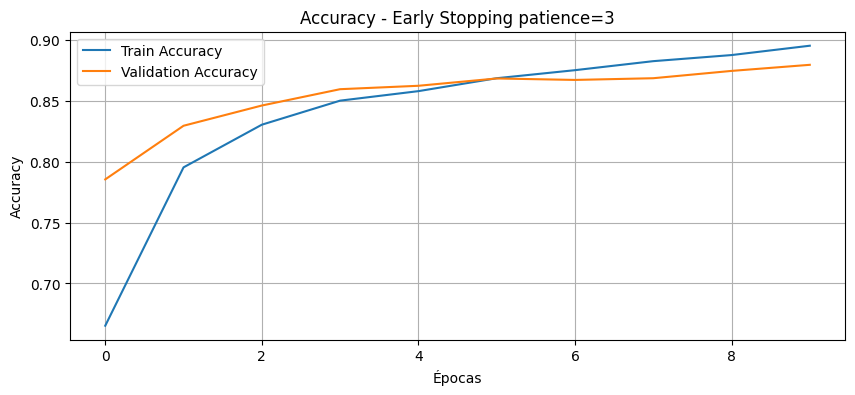

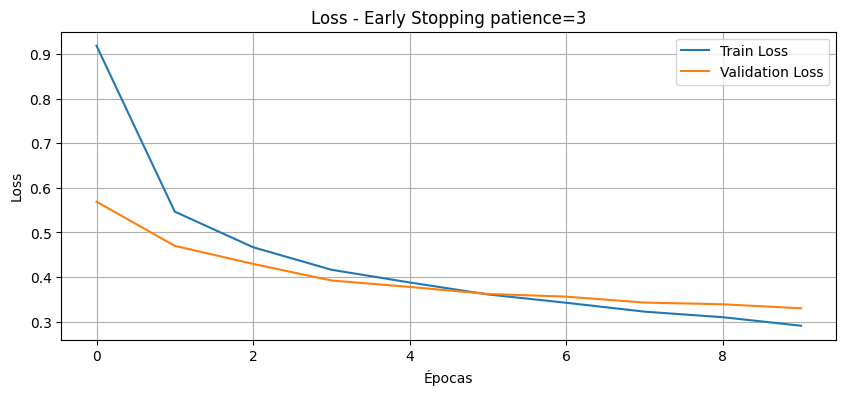

RESULTADOS: Early Stopping patience=3
Train Accuracy:       0.9120
Validation Accuracy:  0.8794
Gap Accuracy:         0.0326
Validation Precision: 0.8817
Validation Recall:    0.8796
Validation F1-score:  0.8802
Epoch 1/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.6755 - loss: 0.9141 - val_accuracy: 0.7944 - val_loss: 0.5698
Epoch 2/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7998 - loss: 0.5414 - val_accuracy: 0.8228 - val_loss: 0.4758
Epoch 3/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8275 - loss: 0.4723 - val_accuracy: 0.8474 - val_loss: 0.4264
Epoch 4/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8476 - loss: 0.4203 - val_accuracy: 0.8548 - val_loss: 0.3959
Epoch 5/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8599 - loss: 0.3836 - val_accuracy: 0.8660 - val_loss: 0.3772
Epoch 6/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8664 - loss: 0.3633 - val_accuracy: 0.8636 - val_loss: 0.3677
Epoch 7/10
118/118 

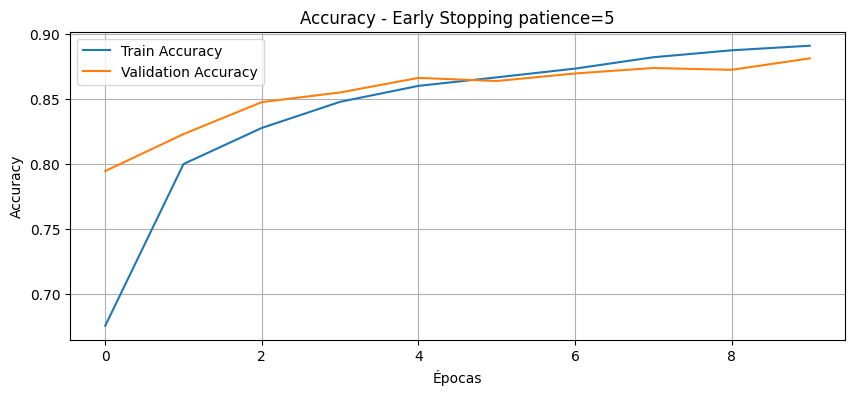

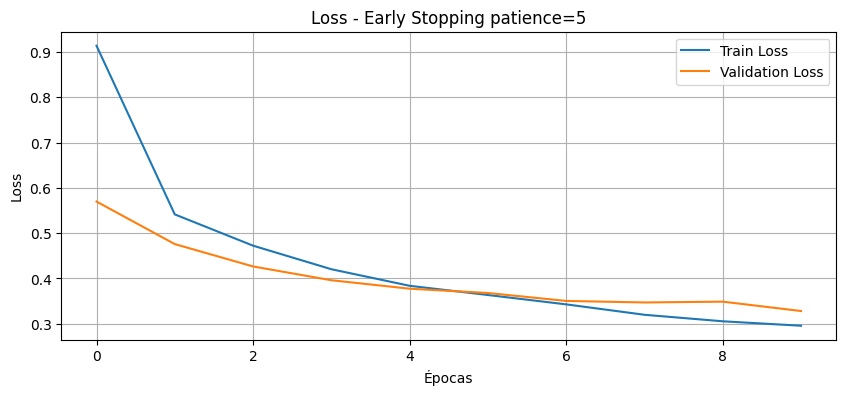

RESULTADOS: Early Stopping patience=5
Train Accuracy:       0.9003
Validation Accuracy:  0.8810
Gap Accuracy:         0.0193
Validation Precision: 0.8810
Validation Recall:    0.8816
Validation F1-score:  0.8805



## 10. Modelo Final Regularizado

El modelo final combina las principales técnicas de regularización:

- L2 Regularization
- Batch Normalization
- Dropout
- Early Stopping

La finalidad es obtener un modelo más equilibrado, que no solo tenga buen accuracy en entrenamiento, sino que también generalice correctamente en validación y test.

Para este modelo final se usa:

- L2 con lambda = 0.001
- Batch Normalization antes de ReLU
- Dropout con tasa 0.3
- Early Stopping monitoreando `val_loss`


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,930 (882.54 KB)

 Trainable params: 225,482 (880.79 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7079 - loss: 1.1157
Epoch 1: val_loss improved from None to 2.65329, saving model to mejor_modelo_regularizado.keras

Epoch 1: finished saving model to mejor_modelo_regularizado.keras
118/118 ━━━━━━━━━━━━━━━━━━━━ 11s 44ms/step - accuracy: 0.7944 - loss: 0.8609 - val_accuracy: 0.1384 - val_loss: 2.6533
Epoch 2/10
117/118 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8683 - loss: 0.6318
Epoch 2: val_loss improved from 2.65329 to 2.49301, saving model to mejor_modelo_regularizado.keras

Epoch 2: finished saving model to mejor_modelo_regularizado.keras
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8763 - loss: 0.5975 - val_accuracy: 0.2080 - val_loss: 2.4930
Epoch 3/10
111/118 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8900 - loss: 0.5233
Epoch 3: val_loss improved from 2.49301 to 1.56949, saving model to mejor_modelo_regularizado.keras

Epoch 3: finished saving model to mejor_modelo_regularizado.keras
118/118

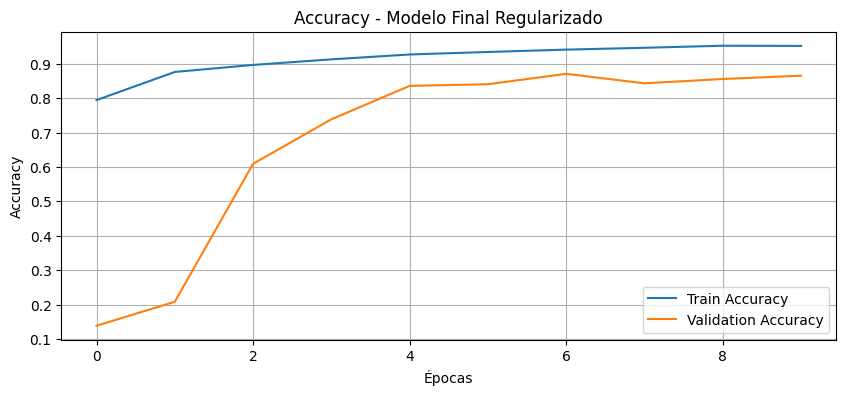

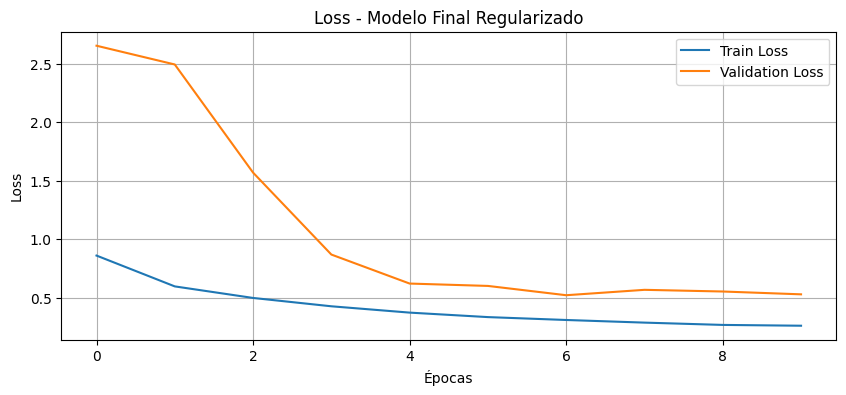

RESULTADOS: Modelo Final Regularizado
Train Accuracy:       0.9367
Validation Accuracy:  0.8708
Gap Accuracy:         0.0659
Validation Precision: 0.8737
Validation Recall:    0.8717
Validation F1-score:  0.8713



## 11. Tabla comparativa global

En esta sección se comparan todos los experimentos realizados.

La tabla incluye métricas de entrenamiento y validación:

- Accuracy
- Precision
- Recall
- F1-score
- Gap entre entrenamiento y validación

El gap entre entrenamiento y validación permite analizar si el modelo presenta sobreajuste.

Un gap menor indica que el modelo tiene un comportamiento más equilibrado entre los datos de entrenamiento y validación.


,Experimento,Train Accuracy,Validation Accuracy,Gap Accuracy,Train Precision,Validation Precision,Train Recall,Validation Recall,Train F1,Validation F1
8,Early Stopping patience=5,0.900333,0.8810,0.019333,0.898341,0.881039,0.899387,0.881583,0.897289,0.880470
7,Early Stopping patience=3,0.912000,0.8794,0.032600,0.911617,0.881661,0.910757,0.879629,0.910592,0.880185
9,Modelo Final Regularizado,0.936667,0.8708,0.065867,0.936795,0.873655,0.936110,0.871685,0.936182,0.871274
3,Dropout rate=0.2,0.861000,0.8464,0.014600,0.857992,0.845900,0.860030,0.847239,0.857010,0.845378
0,Baseline CNN,0.860667,0.8428,0.017867,0.859881,0.842457,0.859927,0.844615,0.852511,0.837781
1,L2 lambda=0.001,0.855667,0.8378,0.017867,0.853043,0.837101,0.854493,0.838527,0.850629,0.836419
4,Dropout rate=0.5,0.855667,0.8364,0.019267,0.852089,0.835242,0.854147,0.837684,0.850632,0.834374
2,L2 lambda=0.01,0.817667,0.7990,0.018667,0.813927,0.795476,0.816556,0.801147,0.799230,0.785732
5,Dropout rate=0.8,0.811667,0.7920,0.019667,0.801576,0.783709,0.810401,0.793915,0.794742,0.781114
6,Batch Normalization,0.666667,0.6462,0.020467,0.793846,0.790270,0.667668,0.650316,0.613466,0.597217


Archivo resultados_experimentos_regularizacion.csv creado correctamente.



## 12. Gráficos comparativos de métricas

A continuación se grafican las métricas principales de validación para comparar el rendimiento de los experimentos.

Se analiza:

- Validation Accuracy
- Validation F1-score
- Gap entre Train Accuracy y Validation Accuracy


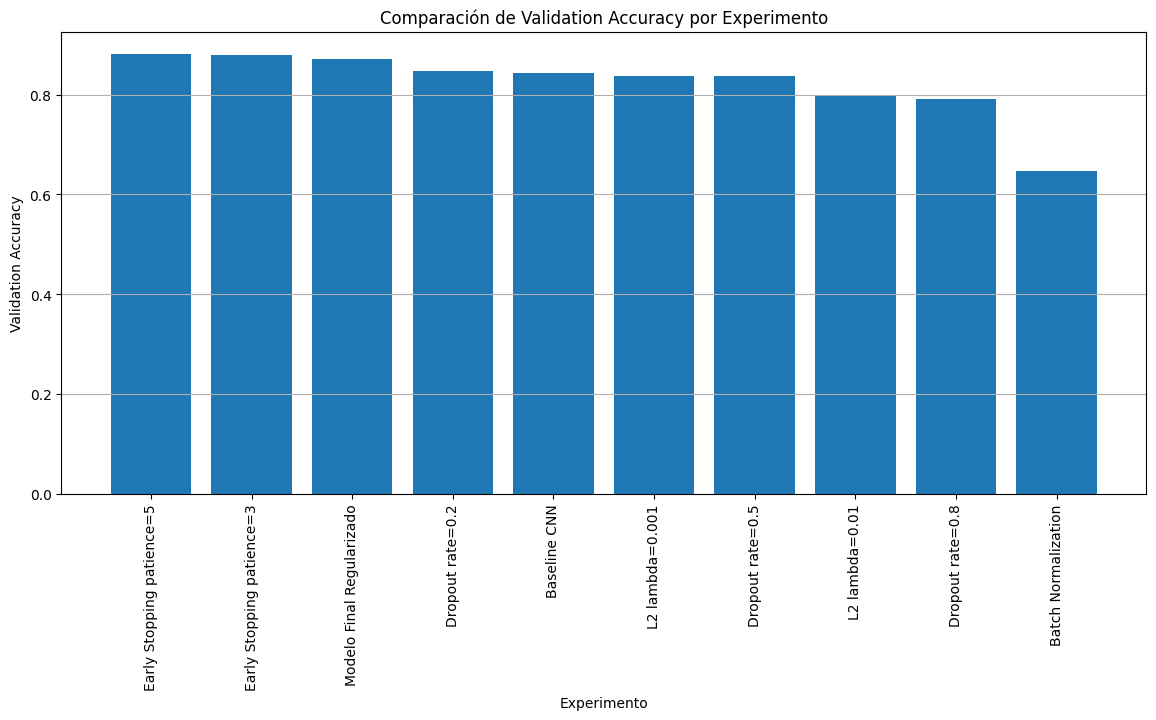

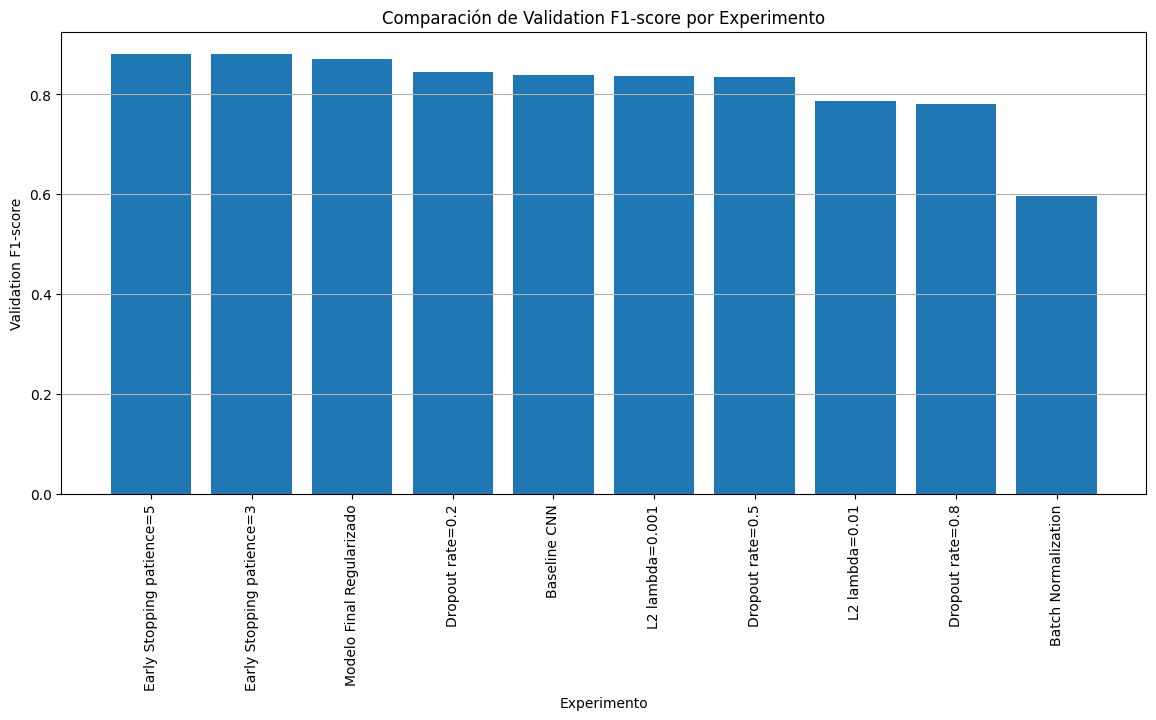

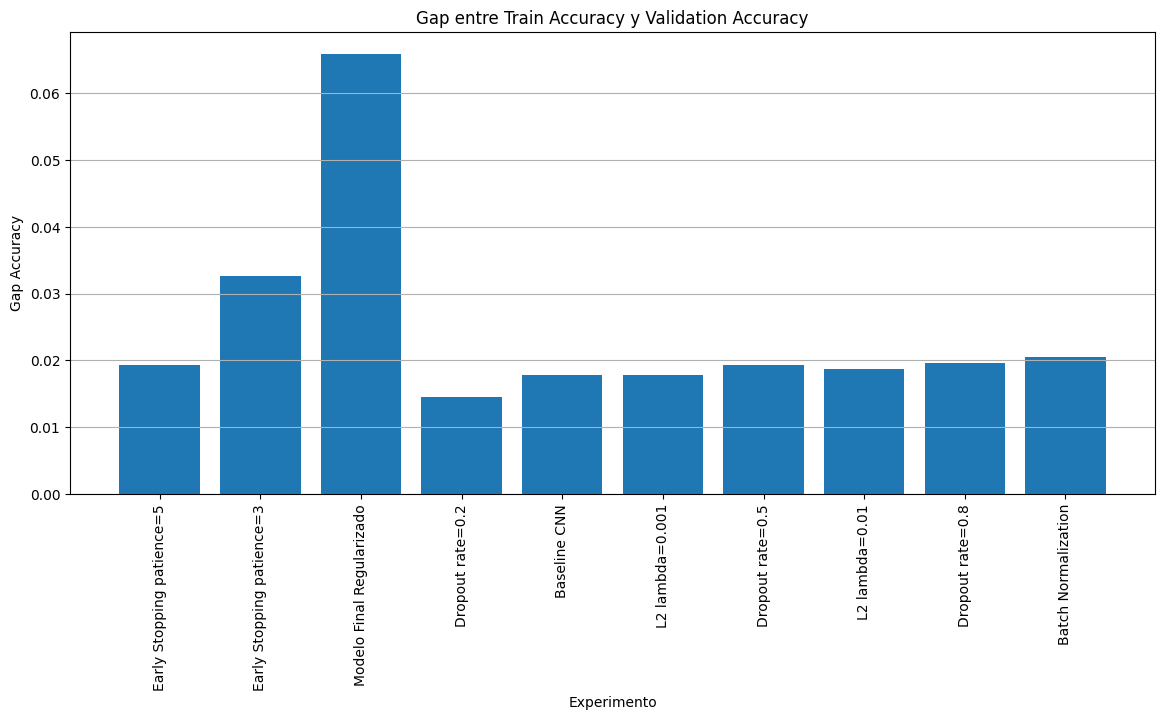


## 13. Comparación Baseline vs Modelo Final

En esta sección se comparan directamente las curvas de validación del modelo baseline y del modelo final regularizado.

Esto permite observar si el modelo final mejora la estabilidad de la validación y reduce el sobreajuste.


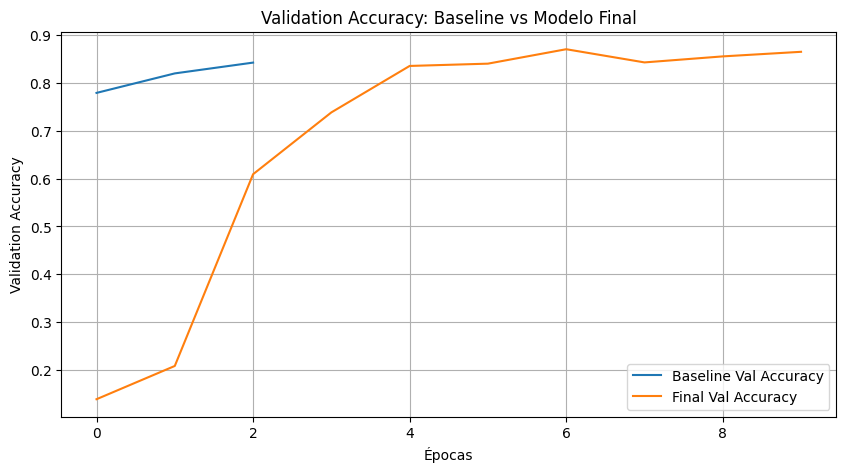

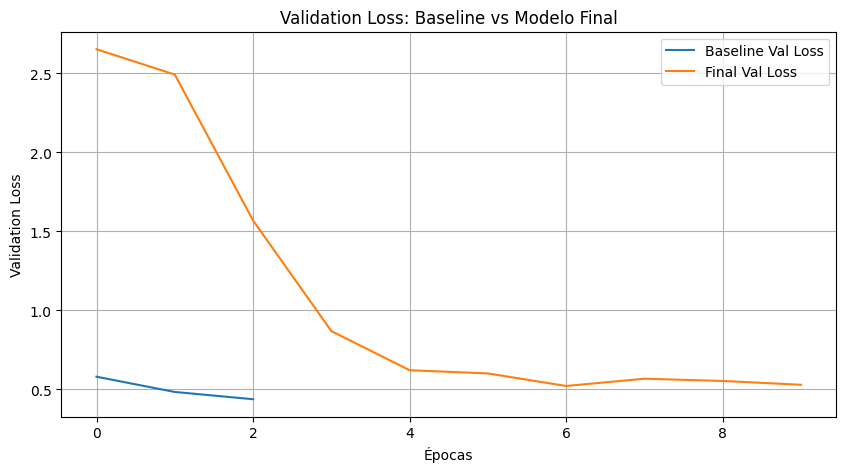


## 14. Evaluación final en test

Después de comparar los modelos, se evalúa el modelo final regularizado sobre el conjunto de test.

El conjunto de test permite medir el rendimiento final con datos que no fueron utilizados durante el entrenamiento ni durante la validación.


RESULTADOS FINALES EN TEST
Test Loss:     0.5239
Test Accuracy: 0.8688
Classification Report - Modelo Final
              precision    recall  f1-score   support

 T-shirt/top       0.86      0.79      0.82       507
     Trouser       0.98      0.98      0.98       481
    Pullover       0.74      0.85      0.79       521
       Dress       0.90      0.87      0.89       500
        Coat       0.81      0.77      0.79       521
      Sandal       0.99      0.89      0.94       485
       Shirt       0.65      0.67      0.66       482
     Sneaker       0.88      0.94      0.91       500
         Bag       0.99      0.95      0.97       526
  Ankle boot       0.93      0.97      0.95       477

    accuracy                           0.87      5000
   macro avg       0.87      0.87      0.87      5000
weighted avg       0.87      0.87      0.87      5000




## 15. Matriz de confusión

La matriz de confusión permite analizar los aciertos y errores del modelo por cada clase.

Esto ayuda a identificar qué categorías son clasificadas correctamente y cuáles generan mayor confusión.


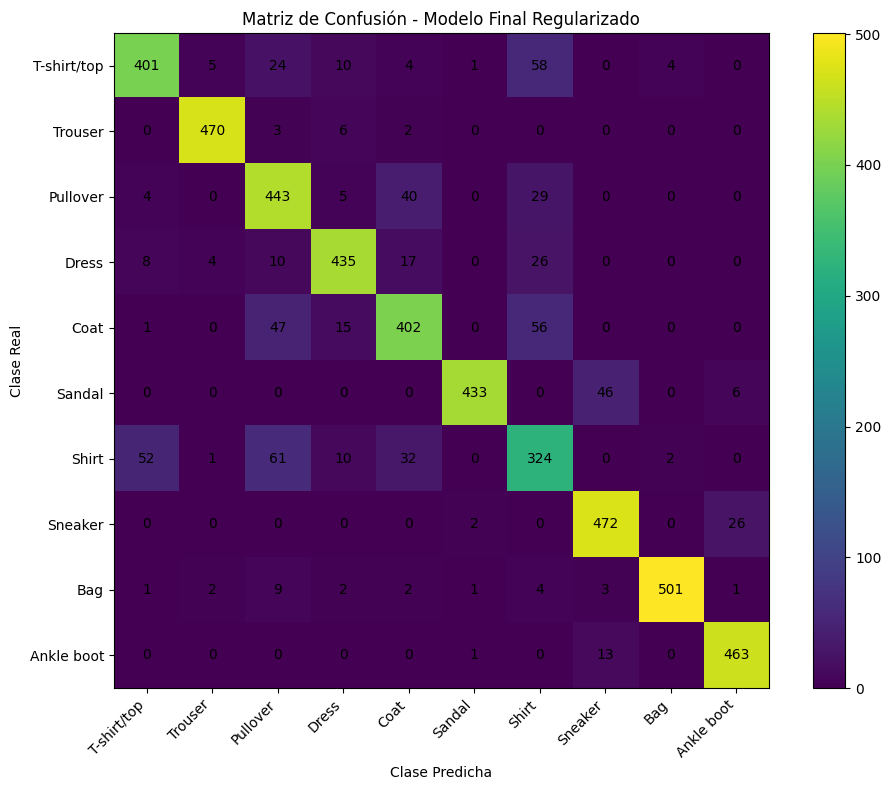


## 16. Predicciones visuales

Se muestran ejemplos del conjunto de test junto con su clase real y la clase predicha por el modelo final.

Esto permite revisar visualmente algunos resultados del modelo.


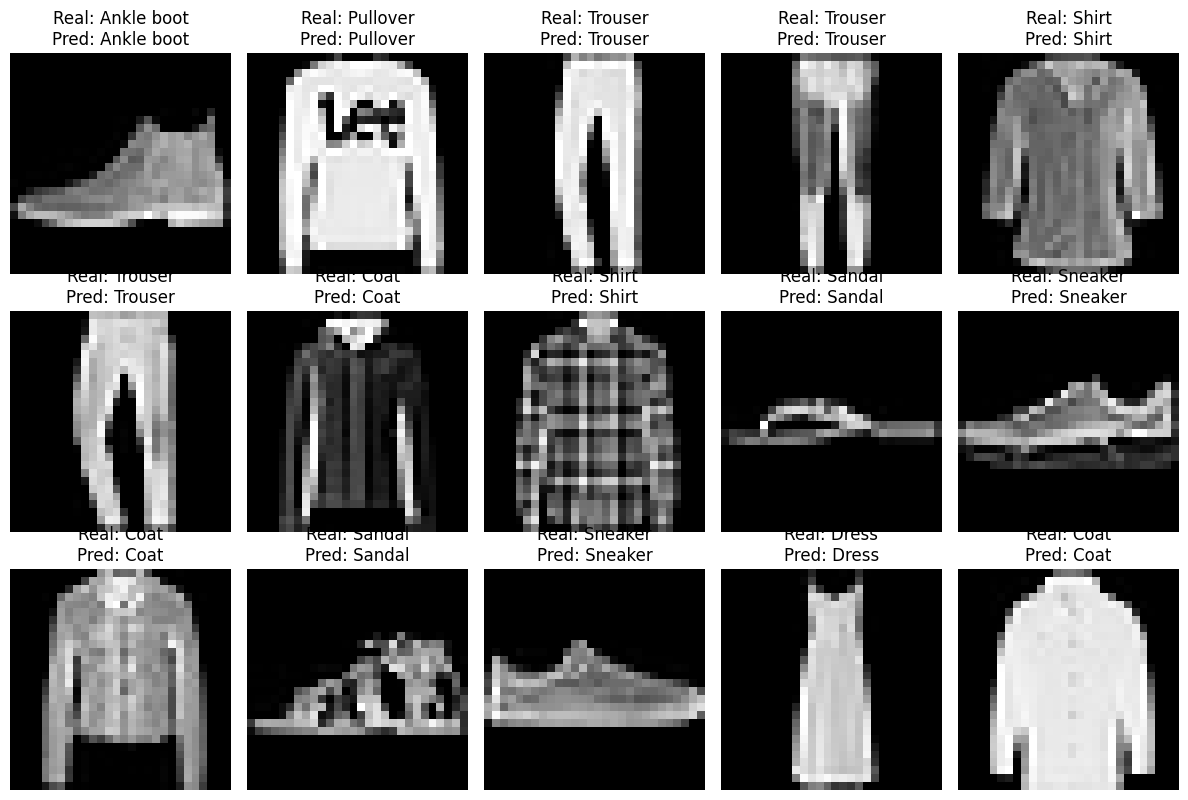


## 17. Análisis del mejor experimento

Se identifica el mejor experimento según el F1-score de validación.

El F1-score es útil porque combina precision y recall, entregando una visión más completa del rendimiento del modelo.


MEJOR EXPERIMENTO SEGÚN VALIDATION F1-SCORE
Experimento:          Early Stopping patience=5
Validation Accuracy:  0.8810
Validation F1-score:  0.8805
Gap Accuracy:         0.0193



## 18. Conclusiones

A partir de los experimentos realizados, se puede concluir que el modelo baseline funciona como punto de comparación para evaluar el impacto de las técnicas de regularización.

L2 Regularization ayuda a controlar el crecimiento de los pesos del modelo, reduciendo la posibilidad de memorización excesiva.

Dropout permite que la red no dependa de neuronas específicas, aunque tasas demasiado altas pueden reducir el aprendizaje.

Batch Normalization estabiliza el entrenamiento al normalizar las activaciones intermedias.

Early Stopping permite detener el entrenamiento cuando la pérdida de validación deja de mejorar, evitando entrenar de más.

El modelo final combina las técnicas anteriores para buscar un mejor equilibrio entre accuracy, F1-score y capacidad de generalización.

En conclusión, el objetivo principal no es obtener el mayor accuracy en entrenamiento, sino lograr que el modelo funcione correctamente con datos nuevos.



## 19. README para GitHub

A continuación se genera un archivo README.md con la descripción del proyecto, técnicas utilizadas, métricas e instrucciones de ejecución.


In [1]:
# ============================================================
# EVALUACIÓN PARCIAL 2 - TÉCNICAS DE REGULARIZACIÓN
# FASHION-MNIST + CNN
# Código completo optimizado para Google Colab
# ============================================================

# ============================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from IPython.display import display, Markdown

from tensorflow.keras import layers, models, regularizers, callbacks
from tensorflow.keras.datasets import fashion_mnist

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# 2. CONFIGURACIÓN GENERAL
# ============================================================

tf.random.set_seed(42)
np.random.seed(42)

# Configuración optimizada para que NO demore tanto
EPOCHS_BASE = 3
EPOCHS_EARLY = 10
BATCH_SIZE = 128

TRAIN_SIZE = 15000
VAL_SIZE = 5000
TEST_SIZE = 5000

print("TensorFlow version:", tf.__version__)

gpu_devices = tf.config.list_physical_devices("GPU")
if gpu_devices:
    print("GPU detectada:", gpu_devices)
else:
    print("No hay GPU activa. El código funcionará, pero será más lento.")





# ============================================================
# TEXTO 2 - CARGA DEL DATASET
# ============================================================

display(Markdown("""
## 1. Carga del dataset

Se utiliza el dataset Fashion-MNIST, que contiene imágenes en escala de grises de prendas de vestir.

Cada imagen tiene un tamaño de 28x28 píxeles y pertenece a una de 10 clases posibles.

La data se carga directamente desde Keras mediante:

`fashion_mnist.load_data()`
"""))

# ============================================================
# 3. CARGA DEL DATASET
# ============================================================

(x_train_full, y_train_full), (x_test_full, y_test_full) = fashion_mnist.load_data()

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

print("Forma original x_train_full:", x_train_full.shape)
print("Forma original y_train_full:", y_train_full.shape)
print("Forma original x_test_full:", x_test_full.shape)
print("Forma original y_test_full:", y_test_full.shape)

# ============================================================
# TEXTO 3 - VISUALIZACIÓN INICIAL
# ============================================================

display(Markdown("""
## 2. Visualización inicial de datos

Antes de entrenar los modelos, se visualizan algunas imágenes del dataset para confirmar que los datos fueron cargados correctamente.

Esto permite verificar las clases y la estructura visual del problema de clasificación.
"""))

# ============================================================
# 4. VISUALIZACIÓN DE IMÁGENES
# ============================================================

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_full[i], cmap="gray")
    plt.title(class_names[y_train_full[i]])
    plt.axis("off")

plt.suptitle("Ejemplos del dataset Fashion-MNIST")
plt.show()

# ============================================================
# TEXTO 4 - PREPROCESAMIENTO
# ============================================================

display(Markdown("""
## 3. Preprocesamiento de datos

Las imágenes se normalizan dividiendo sus valores por 255. Esto deja los píxeles en un rango entre 0 y 1.

Además, se agrega una dimensión extra para que las imágenes sean compatibles con capas convolucionales.

Originalmente, cada imagen tiene forma:

`(28, 28)`

Luego del preprocesamiento queda con forma:

`(28, 28, 1)`

Para reducir el tiempo de ejecución, se utilizarán:

- 15.000 imágenes para entrenamiento
- 5.000 imágenes para validación
- 5.000 imágenes para test
"""))

# ============================================================
# 5. PREPROCESAMIENTO OPTIMIZADO
# ============================================================

# Normalización
x_train_full = x_train_full.astype("float32") / 255.0
x_test_full = x_test_full.astype("float32") / 255.0

# Agregar canal para CNN: de (28, 28) a (28, 28, 1)
x_train_full = np.expand_dims(x_train_full, axis=-1)
x_test_full = np.expand_dims(x_test_full, axis=-1)

# Usar muestra reducida para que el entrenamiento sea rápido
x_train = x_train_full[:TRAIN_SIZE]
y_train = y_train_full[:TRAIN_SIZE]

x_val = x_train_full[TRAIN_SIZE:TRAIN_SIZE + VAL_SIZE]
y_val = y_train_full[TRAIN_SIZE:TRAIN_SIZE + VAL_SIZE]

x_test = x_test_full[:TEST_SIZE]
y_test = y_test_full[:TEST_SIZE]

print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_val:", x_val.shape)
print("y_val:", y_val.shape)
print("x_test:", x_test.shape)
print("y_test:", y_test.shape)

# ============================================================
# TEXTO 5 - FUNCIONES AUXILIARES
# ============================================================

display(Markdown("""
## 4. Funciones auxiliares

Se crean funciones reutilizables para:

- Compilar modelos
- Graficar accuracy y loss
- Evaluar modelos
- Guardar los resultados en una tabla comparativa

Para acelerar la evaluación, las métricas de entrenamiento se calcularán sobre una muestra de 3.000 registros.
"""))

# ============================================================
# 6. FUNCIONES AUXILIARES
# ============================================================

results = []
histories = {}

def compile_model(model):
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


def plot_history(history, title):
    plt.figure(figsize=(10, 4))
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"Accuracy - {title}")
    plt.xlabel("Épocas")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"Loss - {title}")
    plt.xlabel("Épocas")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()


def evaluate_model(model, experiment_name):
    """
    Evalúa el modelo de forma optimizada.
    Para train usa solo 3.000 imágenes para ahorrar tiempo.
    Para validación usa todo x_val.
    """

    x_train_sample = x_train[:3000]
    y_train_sample = y_train[:3000]

    y_train_pred = np.argmax(model.predict(x_train_sample, verbose=0), axis=1)
    y_val_pred = np.argmax(model.predict(x_val, verbose=0), axis=1)

    train_accuracy = accuracy_score(y_train_sample, y_train_pred)
    val_accuracy = accuracy_score(y_val, y_val_pred)

    train_precision = precision_score(y_train_sample, y_train_pred, average="macro", zero_division=0)
    val_precision = precision_score(y_val, y_val_pred, average="macro", zero_division=0)

    train_recall = recall_score(y_train_sample, y_train_pred, average="macro", zero_division=0)
    val_recall = recall_score(y_val, y_val_pred, average="macro", zero_division=0)

    train_f1 = f1_score(y_train_sample, y_train_pred, average="macro", zero_division=0)
    val_f1 = f1_score(y_val, y_val_pred, average="macro", zero_division=0)

    gap_accuracy = train_accuracy - val_accuracy

    results.append({
        "Experimento": experiment_name,
        "Train Accuracy": train_accuracy,
        "Validation Accuracy": val_accuracy,
        "Gap Accuracy": gap_accuracy,
        "Train Precision": train_precision,
        "Validation Precision": val_precision,
        "Train Recall": train_recall,
        "Validation Recall": val_recall,
        "Train F1": train_f1,
        "Validation F1": val_f1
    })

    print("====================================================")
    print(f"RESULTADOS: {experiment_name}")
    print("====================================================")
    print(f"Train Accuracy:       {train_accuracy:.4f}")
    print(f"Validation Accuracy:  {val_accuracy:.4f}")
    print(f"Gap Accuracy:         {gap_accuracy:.4f}")
    print(f"Validation Precision: {val_precision:.4f}")
    print(f"Validation Recall:    {val_recall:.4f}")
    print(f"Validation F1-score:  {val_f1:.4f}")
    print("====================================================")

# ============================================================
# TEXTO 6 - MODELO BASELINE
# ============================================================

display(Markdown("""
## 5. Modelo Baseline

El modelo baseline corresponde al modelo base utilizado en la Evaluación Parcial 1.

Este modelo se usa como referencia para comparar el impacto de las técnicas de regularización.

La arquitectura base utiliza:

- Conv2D
- MaxPooling2D
- Conv2D
- MaxPooling2D
- Flatten
- Dense
- Dropout
- Dense de salida con Softmax

Este modelo permitirá observar si existe diferencia entre el rendimiento de entrenamiento y validación.
"""))

# ============================================================
# 7. MODELO BASELINE
# ============================================================

def build_baseline_model():
    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),

        layers.Conv2D(32, kernel_size=3, activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(64, kernel_size=3, activation="relu"),
        layers.MaxPooling2D(),

        layers.Flatten(),

        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),

        layers.Dense(10, activation="softmax")
    ])

    return compile_model(model)


baseline_model = build_baseline_model()
baseline_model.summary()

history_baseline = baseline_model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS_BASE,
    batch_size=BATCH_SIZE,
    verbose=1
)

histories["Baseline CNN"] = history_baseline

plot_history(history_baseline, "Baseline CNN")
evaluate_model(baseline_model, "Baseline CNN")

# ============================================================
# TEXTO 7 - L2 REGULARIZATION
# ============================================================

display(Markdown("""
## 6. L2 Regularization

La regularización L2 penaliza pesos grandes dentro del modelo.

Esto ayuda a reducir el sobreajuste, evitando que la red memorice excesivamente los datos de entrenamiento.

Se prueban dos valores de lambda:

- 0.001
- 0.01

Un valor pequeño aplica una penalización suave, mientras que un valor más alto aplica una penalización más fuerte.

El objetivo es observar cuál valor reduce mejor el gap entre entrenamiento y validación.
"""))

# ============================================================
# 8. L2 REGULARIZATION
# ============================================================

def build_l2_model(lambda_value):
    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),

        layers.Conv2D(
            32,
            kernel_size=3,
            activation="relu",
            kernel_regularizer=regularizers.l2(lambda_value)
        ),
        layers.MaxPooling2D(),

        layers.Conv2D(
            64,
            kernel_size=3,
            activation="relu",
            kernel_regularizer=regularizers.l2(lambda_value)
        ),
        layers.MaxPooling2D(),

        layers.Flatten(),

        layers.Dense(
            128,
            activation="relu",
            kernel_regularizer=regularizers.l2(lambda_value)
        ),
        layers.Dropout(0.3),

        layers.Dense(10, activation="softmax")
    ])

    return compile_model(model)


for lambda_value in [0.001, 0.01]:
    experiment_name = f"L2 lambda={lambda_value}"

    model_l2 = build_l2_model(lambda_value)

    history_l2 = model_l2.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=EPOCHS_BASE,
        batch_size=BATCH_SIZE,
        verbose=1
    )

    histories[experiment_name] = history_l2

    plot_history(history_l2, experiment_name)
    evaluate_model(model_l2, experiment_name)

# ============================================================
# TEXTO 8 - DROPOUT
# ============================================================

display(Markdown("""
## 7. Dropout

Dropout desactiva aleatoriamente una proporción de neuronas durante el entrenamiento.

Esto permite que la red no dependa de neuronas específicas y ayuda a mejorar la generalización.

Se prueban tres tasas:

- 0.2
- 0.5
- 0.8

Una tasa baja puede tener poco efecto regularizador.

Una tasa demasiado alta puede afectar negativamente el aprendizaje, ya que elimina demasiada información durante el entrenamiento.
"""))

# ============================================================
# 9. DROPOUT
# ============================================================

def build_dropout_model(dropout_rate):
    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),

        layers.Conv2D(32, kernel_size=3, activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(64, kernel_size=3, activation="relu"),
        layers.MaxPooling2D(),

        layers.Flatten(),

        layers.Dense(128, activation="relu"),
        layers.Dropout(dropout_rate),

        layers.Dense(10, activation="softmax")
    ])

    return compile_model(model)


for dropout_rate in [0.2, 0.5, 0.8]:
    experiment_name = f"Dropout rate={dropout_rate}"

    model_dropout = build_dropout_model(dropout_rate)

    history_dropout = model_dropout.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=EPOCHS_BASE,
        batch_size=BATCH_SIZE,
        verbose=1
    )

    histories[experiment_name] = history_dropout

    plot_history(history_dropout, experiment_name)
    evaluate_model(model_dropout, experiment_name)

# ============================================================
# TEXTO 9 - BATCH NORMALIZATION
# ============================================================

display(Markdown("""
## 8. Batch Normalization

Batch Normalization normaliza las activaciones intermedias del modelo.

Esto puede estabilizar el entrenamiento y mejorar la convergencia.

En esta arquitectura se ubica BatchNormalization después de la capa convolucional o densa y antes de la activación ReLU.

Esto permite normalizar la salida de la capa antes de aplicar la función de activación.
"""))

# ============================================================
# 10. BATCH NORMALIZATION
# ============================================================

def build_batchnorm_model():
    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),

        layers.Conv2D(32, kernel_size=3),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(64, kernel_size=3),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(),

        layers.Flatten(),

        layers.Dense(128),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Dropout(0.3),

        layers.Dense(10, activation="softmax")
    ])

    return compile_model(model)


batchnorm_model = build_batchnorm_model()
batchnorm_model.summary()

history_batchnorm = batchnorm_model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS_BASE,
    batch_size=BATCH_SIZE,
    verbose=1
)

histories["Batch Normalization"] = history_batchnorm

plot_history(history_batchnorm, "Batch Normalization")
evaluate_model(batchnorm_model, "Batch Normalization")

# ============================================================
# TEXTO 10 - EARLY STOPPING
# ============================================================

display(Markdown("""
## 9. Early Stopping

Early Stopping detiene el entrenamiento cuando la pérdida de validación deja de mejorar.

Se monitorea `val_loss`, porque representa el rendimiento del modelo en datos que no se usan directamente para entrenar.

Se prueban dos valores:

- patience = 3
- patience = 5

Se utiliza `restore_best_weights=True` para recuperar los mejores pesos encontrados durante el entrenamiento.
"""))

# ============================================================
# 11. EARLY STOPPING
# ============================================================

def build_early_stopping_model():
    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),

        layers.Conv2D(32, kernel_size=3, activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(64, kernel_size=3, activation="relu"),
        layers.MaxPooling2D(),

        layers.Flatten(),

        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),

        layers.Dense(10, activation="softmax")
    ])

    return compile_model(model)


for patience_value in [3, 5]:
    experiment_name = f"Early Stopping patience={patience_value}"

    early_stop = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=patience_value,
        restore_best_weights=True
    )

    model_early = build_early_stopping_model()

    history_early = model_early.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=EPOCHS_EARLY,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        verbose=1
    )

    histories[experiment_name] = history_early

    print(f"{experiment_name} se detuvo en la época: {len(history_early.history['loss'])}")

    plot_history(history_early, experiment_name)
    evaluate_model(model_early, experiment_name)

# ============================================================
# TEXTO 11 - MODELO FINAL REGULARIZADO
# ============================================================

display(Markdown("""
## 10. Modelo Final Regularizado

El modelo final combina las principales técnicas de regularización:

- L2 Regularization
- Batch Normalization
- Dropout
- Early Stopping

La finalidad es obtener un modelo más equilibrado, que no solo tenga buen accuracy en entrenamiento, sino que también generalice correctamente en validación y test.

Para este modelo final se usa:

- L2 con lambda = 0.001
- Batch Normalization antes de ReLU
- Dropout con tasa 0.3
- Early Stopping monitoreando `val_loss`
"""))

# ============================================================
# 12. MODELO FINAL REGULARIZADO
# ============================================================

def build_final_model():
    l2_value = 0.001

    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),

        layers.Conv2D(
            32,
            kernel_size=3,
            kernel_regularizer=regularizers.l2(l2_value)
        ),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(
            64,
            kernel_size=3,
            kernel_regularizer=regularizers.l2(l2_value)
        ),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(),

        layers.Flatten(),

        layers.Dense(
            128,
            kernel_regularizer=regularizers.l2(l2_value)
        ),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Dropout(0.3),

        layers.Dense(10, activation="softmax")
    ])

    return compile_model(model)


early_stop_final = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = callbacks.ModelCheckpoint(
    "mejor_modelo_regularizado.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

final_model = build_final_model()
final_model.summary()

history_final = final_model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS_EARLY,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop_final, checkpoint],
    verbose=1
)

histories["Modelo Final Regularizado"] = history_final

print(f"Modelo final se detuvo en la época: {len(history_final.history['loss'])}")

plot_history(history_final, "Modelo Final Regularizado")
evaluate_model(final_model, "Modelo Final Regularizado")

# ============================================================
# TEXTO 12 - TABLA COMPARATIVA GLOBAL
# ============================================================

display(Markdown("""
## 11. Tabla comparativa global

En esta sección se comparan todos los experimentos realizados.

La tabla incluye métricas de entrenamiento y validación:

- Accuracy
- Precision
- Recall
- F1-score
- Gap entre entrenamiento y validación

El gap entre entrenamiento y validación permite analizar si el modelo presenta sobreajuste.

Un gap menor indica que el modelo tiene un comportamiento más equilibrado entre los datos de entrenamiento y validación.
"""))

# ============================================================
# 13. TABLA COMPARATIVA GLOBAL
# ============================================================

df_results = pd.DataFrame(results)

df_results_sorted = df_results.sort_values(
    by=["Validation F1", "Validation Accuracy"],
    ascending=False
)

display(df_results_sorted)

df_results_sorted.to_csv("resultados_experimentos_regularizacion.csv", index=False)

print("Archivo resultados_experimentos_regularizacion.csv creado correctamente.")

# ============================================================
# TEXTO 13 - GRÁFICOS COMPARATIVOS
# ============================================================

display(Markdown("""
## 12. Gráficos comparativos de métricas

A continuación se grafican las métricas principales de validación para comparar el rendimiento de los experimentos.

Se analiza:

- Validation Accuracy
- Validation F1-score
- Gap entre Train Accuracy y Validation Accuracy
"""))

# ============================================================
# 14. GRÁFICOS COMPARATIVOS
# ============================================================

plt.figure(figsize=(14, 6))
plt.bar(df_results_sorted["Experimento"], df_results_sorted["Validation Accuracy"])
plt.xticks(rotation=90)
plt.title("Comparación de Validation Accuracy por Experimento")
plt.xlabel("Experimento")
plt.ylabel("Validation Accuracy")
plt.grid(axis="y")
plt.show()

plt.figure(figsize=(14, 6))
plt.bar(df_results_sorted["Experimento"], df_results_sorted["Validation F1"])
plt.xticks(rotation=90)
plt.title("Comparación de Validation F1-score por Experimento")
plt.xlabel("Experimento")
plt.ylabel("Validation F1-score")
plt.grid(axis="y")
plt.show()

plt.figure(figsize=(14, 6))
plt.bar(df_results_sorted["Experimento"], df_results_sorted["Gap Accuracy"])
plt.xticks(rotation=90)
plt.title("Gap entre Train Accuracy y Validation Accuracy")
plt.xlabel("Experimento")
plt.ylabel("Gap Accuracy")
plt.grid(axis="y")
plt.show()

# ============================================================
# TEXTO 14 - BASELINE VS MODELO FINAL
# ============================================================

display(Markdown("""
## 13. Comparación Baseline vs Modelo Final

En esta sección se comparan directamente las curvas de validación del modelo baseline y del modelo final regularizado.

Esto permite observar si el modelo final mejora la estabilidad de la validación y reduce el sobreajuste.
"""))

# ============================================================
# 15. COMPARACIÓN BASELINE VS MODELO FINAL
# ============================================================

plt.figure(figsize=(10, 5))
plt.plot(history_baseline.history["val_accuracy"], label="Baseline Val Accuracy")
plt.plot(history_final.history["val_accuracy"], label="Final Val Accuracy")
plt.title("Validation Accuracy: Baseline vs Modelo Final")
plt.xlabel("Épocas")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_baseline.history["val_loss"], label="Baseline Val Loss")
plt.plot(history_final.history["val_loss"], label="Final Val Loss")
plt.title("Validation Loss: Baseline vs Modelo Final")
plt.xlabel("Épocas")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# TEXTO 15 - EVALUACIÓN FINAL EN TEST
# ============================================================

display(Markdown("""
## 14. Evaluación final en test

Después de comparar los modelos, se evalúa el modelo final regularizado sobre el conjunto de test.

El conjunto de test permite medir el rendimiento final con datos que no fueron utilizados durante el entrenamiento ni durante la validación.
"""))

# ============================================================
# 16. EVALUACIÓN FINAL EN TEST
# ============================================================

test_loss, test_accuracy = final_model.evaluate(x_test, y_test, verbose=0)

print("====================================================")
print("RESULTADOS FINALES EN TEST")
print("====================================================")
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print("====================================================")

y_test_pred = np.argmax(final_model.predict(x_test, verbose=0), axis=1)

print("Classification Report - Modelo Final")
print(classification_report(y_test, y_test_pred, target_names=class_names, zero_division=0))

# ============================================================
# TEXTO 16 - MATRIZ DE CONFUSIÓN
# ============================================================

display(Markdown("""
## 15. Matriz de confusión

La matriz de confusión permite analizar los aciertos y errores del modelo por cada clase.

Esto ayuda a identificar qué categorías son clasificadas correctamente y cuáles generan mayor confusión.
"""))

# ============================================================
# 17. MATRIZ DE CONFUSIÓN
# ============================================================

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm)
plt.title("Matriz de Confusión - Modelo Final Regularizado")
plt.xlabel("Clase Predicha")
plt.ylabel("Clase Real")
plt.xticks(np.arange(10), class_names, rotation=45, ha="right")
plt.yticks(np.arange(10), class_names)
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

# ============================================================
# TEXTO 17 - PREDICCIONES VISUALES
# ============================================================

display(Markdown("""
## 16. Predicciones visuales

Se muestran ejemplos del conjunto de test junto con su clase real y la clase predicha por el modelo final.

Esto permite revisar visualmente algunos resultados del modelo.
"""))

# ============================================================
# 18. PREDICCIONES VISUALES
# ============================================================

plt.figure(figsize=(12, 8))

for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")

    real_label = class_names[y_test[i]]
    pred_label = class_names[y_test_pred[i]]

    plt.title(f"Real: {real_label}\nPred: {pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# TEXTO 18 - MEJOR EXPERIMENTO
# ============================================================

display(Markdown("""
## 17. Análisis del mejor experimento

Se identifica el mejor experimento según el F1-score de validación.

El F1-score es útil porque combina precision y recall, entregando una visión más completa del rendimiento del modelo.
"""))

# ============================================================
# 19. MEJOR EXPERIMENTO
# ============================================================

best_experiment = df_results_sorted.iloc[0]

print("====================================================")
print("MEJOR EXPERIMENTO SEGÚN VALIDATION F1-SCORE")
print("====================================================")
print(f"Experimento:          {best_experiment['Experimento']}")
print(f"Validation Accuracy:  {best_experiment['Validation Accuracy']:.4f}")
print(f"Validation F1-score:  {best_experiment['Validation F1']:.4f}")
print(f"Gap Accuracy:         {best_experiment['Gap Accuracy']:.4f}")
print("====================================================")

# ============================================================
# TEXTO 19 - CONCLUSIONES
# ============================================================

display(Markdown("""
## 18. Conclusiones

A partir de los experimentos realizados, se puede concluir que el modelo baseline funciona como punto de comparación para evaluar el impacto de las técnicas de regularización.

L2 Regularization ayuda a controlar el crecimiento de los pesos del modelo, reduciendo la posibilidad de memorización excesiva.

Dropout permite que la red no dependa de neuronas específicas, aunque tasas demasiado altas pueden reducir el aprendizaje.

Batch Normalization estabiliza el entrenamiento al normalizar las activaciones intermedias.

Early Stopping permite detener el entrenamiento cuando la pérdida de validación deja de mejorar, evitando entrenar de más.

El modelo final combina las técnicas anteriores para buscar un mejor equilibrio entre accuracy, F1-score y capacidad de generalización.

En conclusión, el objetivo principal no es obtener el mayor accuracy en entrenamiento, sino lograr que el modelo funcione correctamente con datos nuevos.
"""))

# ============================================================
# TEXTO 20 - README PARA GITHUB
# ============================================================

display(Markdown("""
## 19. README para GitHub

A continuación se genera un archivo README.md con la descripción del proyecto, técnicas utilizadas, métricas e instrucciones de ejecución.
"""))

# ============================================================
# 20. CREACIÓN DE README
# ============================================================

readme_text = """
# Evaluación Parcial 2 - Técnicas de Regularización en Deep Learning

## Descripción

Este proyecto corresponde a la Evaluación Parcial 2 de la asignatura Deep Learning.

Se utiliza el dataset Fashion-MNIST y un modelo CNN basado en el trabajo realizado en la Evaluación Parcial 1.

El objetivo principal es aplicar técnicas de regularización para reducir el sobreajuste y mejorar la capacidad de generalización del modelo.

## Dataset

Fashion-MNIST contiene imágenes en escala de grises de 28x28 píxeles correspondientes a 10 categorías de prendas de vestir.

## Técnicas implementadas

- Modelo baseline CNN
- L2 Regularization
- Dropout
- Batch Normalization
- Early Stopping
- Modelo final combinado

## Métricas utilizadas

- Accuracy
- Precision
- Recall
- F1-score
- Gap entre entrenamiento y validación
- Curvas de loss y accuracy
- Matriz de confusión

## Archivos generados

- resultados_experimentos_regularizacion.csv
- mejor_modelo_regularizado.keras
- README.md

## Instrucciones de ejecución

1. Abrir el notebook en Google Colab.
2. Activar GPU en Entorno de ejecución.
3. Ejecutar todas las celdas en orden.
4. Revisar los gráficos generados.
5. Revisar la tabla comparativa de experimentos.
6. Analizar el modelo final sobre el conjunto de test.

## Conclusión

La combinación de técnicas de regularización permite mejorar la capacidad de generalización del modelo, reduciendo el riesgo de overfitting.
"""

with open("README.md", "w", encoding="utf-8") as file:
    file.write(readme_text)


